# LightGBM Baseline Model

**Module:** IT3051 - Fundamentals of Data Mining
**Project:** Next-Year PM2.5 Air-Quality Risk Classification
**Model:** LightGBM Classifier
**Purpose:** Baseline model development and validation

This notebook:

* Loads the chronological train, validation, and test datasets
* Reuses the project preprocessing pipeline
* Fits preprocessing only on the training data to prevent data leakage
* Trains a baseline LightGBM classifier
* Evaluates the model on the chronological validation set
* Reports Accuracy, Macro F1, classification results, and confusion matrix
* Analyses feature importance
* Saves the baseline model results and visualizations
* Keeps the test set untouched for later final model evaluation

> This notebook focuses on establishing a baseline LightGBM model. Hyperparameter tuning is performed separately in `16_lightgbm_hyperparameter_tuning.ipynb`.


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Add project root to Python path
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.preprocessing_pipeline import (
    TARGET_COLUMN,
    prepare_base_dataframe,
    prepare_features_and_target,
    build_preprocessor,
)

print("Imports loaded successfully.")
print("Project root:", project_root)

Imports loaded successfully.
Project root: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project


## 1. Load Chronological Split Datasets

The project dataset is divided chronologically into training, validation, and test sets.

* **Training:** Historical data up to 2012
* **Validation:** Data from 2013–2014
* **Test:** Data from 2015–2016

The split datasets are loaded from the project's processed data directory.

The identifier columns are explicitly loaded as strings to preserve their original values and data types.


In [3]:
processed_dir = project_root / "data" / "processed"

train_path = processed_dir / "train_data.csv"
validation_path = processed_dir / "validation_data.csv"
test_path = processed_dir / "test_data.csv"

required_files = [train_path, validation_path, test_path]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run 07_make_dataset.ipynb first to create the chronological split files."
        )

identifier_types = {
    "site_id": "string",
    "state_code": "string",
    "county_code": "string",
    "site_num": "string",
}

train_df = pd.read_csv(
    train_path,
    dtype=identifier_types,
    low_memory=False
)

validation_df = pd.read_csv(
    validation_path,
    dtype=identifier_types,
    low_memory=False
)

test_df = pd.read_csv(
    test_path,
    dtype=identifier_types,
    low_memory=False
)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 2. Confirm the Chronological Split

The year ranges of the training, validation, and test datasets are checked to confirm that the chronological split has been preserved.

This ensures that future observations are not included in the training data and helps prevent temporal data leakage.


In [4]:
for name, dataset in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(
        f"{name}: {dataset['year'].min()} - {dataset['year'].max()} "
        f"({len(dataset)} rows)"
    )

Training: 1997 - 2012 (13191 rows)
Validation: 2013 - 2014 (1783 rows)
Test: 2015 - 2016 (1561 rows)


## 3. Apply Base Cleaning to Each Split

The same base-cleaning function from the project preprocessing pipeline is applied to the training, validation, and test datasets.

Each dataset split is processed using the same preprocessing logic to maintain consistency across the experiment.


In [5]:
train_prepared = prepare_base_dataframe(train_df)
validation_prepared = prepare_base_dataframe(validation_df)
test_prepared = prepare_base_dataframe(test_df)

print("Base preprocessing completed.")

Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Base preprocessing completed.


## 4. Separate Features and Target

The target variable is separated from the predictor variables using the project's preprocessing pipeline.

The existing `prepare_features_and_target()` function also excludes the identifier columns that are not used as predictive features.

The training target distribution is displayed to understand the class distribution before model training.


In [6]:
X_train, y_train = prepare_features_and_target(train_prepared)
X_val, y_val = prepare_features_and_target(validation_prepared)
X_test, y_test = prepare_features_and_target(test_prepared)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
X_train: (13191, 33) | y_train: (13191,)
X_val: (1783, 33) | y_val: (1783,)
X_test: (1561, 33) | y_test: (1561,)

Training target distribution:
pm25_risk_category_next_year
Moderate                          6849
Unhealthy for Sensitive Groups    5049
Unhealthy                         1203
Good                                52
Very Unhealthy                      38
Name: count, dtype: int64


## 5. Fit the Preprocessing Pipeline

The preprocessing pipeline is built using the training features and then fitted only on the training data.

The fitted preprocessor is applied to the training, validation, and test features using the same transformations.

This approach prevents data leakage because the validation and test data are only transformed using preprocessing information learned from the training data.

The processed feature shapes are also checked to confirm that the transformation was applied consistently across all three datasets.


In [7]:
preprocessor = build_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Numerical features: 29
Categorical features: 4
Preprocessing completed.
Processed training shape: (13191, 2154)
Processed validation shape: (1783, 2154)
Processed test shape: (1561, 2154)


## 6. Train the Baseline LightGBM Model

A baseline LightGBM classifier is trained using the preprocessed training data.

The model uses the default LightGBM hyperparameters, with a fixed random state to ensure reproducible results and all available CPU cores for efficient training.

This baseline model provides a reference point for evaluating the performance of LightGBM before applying hyperparameter tuning.


In [8]:
lgbm_baseline = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_baseline.fit(
    X_train_processed,
    y_train
)

print("LightGBM baseline model trained successfully!")

LightGBM baseline model trained successfully!


## 7. Generate Validation Predictions

The trained baseline LightGBM model is used to generate predictions for the chronological validation dataset.

The validation set is kept separate from the training process and is used to evaluate how well the baseline model performs on unseen data.


In [9]:
y_val_pred = lgbm_baseline.predict(X_val_processed)

print("Validation predictions generated successfully!")
print("Number of predictions:", len(y_val_pred))

Validation predictions generated successfully!
Number of predictions: 1783


## 8. Evaluate Baseline Performance

The baseline LightGBM model is evaluated on the chronological validation set using three performance metrics:

* **Accuracy** – measures the overall proportion of correctly classified observations.
* **Macro F1** – calculates the F1-score independently for each class and then gives equal importance to all classes.
* **Weighted F1** – calculates the F1-score for each class while accounting for the number of observations in each class.

Macro F1 is particularly important for this project because the target classes are imbalanced.


In [10]:
accuracy = accuracy_score(y_val, y_val_pred)

macro_f1 = f1_score(
    y_val,
    y_val_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_val,
    y_val_pred,
    average="weighted"
)

print(f"Validation Accuracy  : {accuracy:.4f}")
print(f"Validation Macro F1   : {macro_f1:.4f}")
print(f"Validation Weighted F1: {weighted_f1:.4f}")

Validation Accuracy  : 0.7644
Validation Macro F1   : 0.3207
Validation Weighted F1: 0.7241


## 9. Generate the Classification Report

A detailed classification report is generated for the validation predictions.

The report provides **precision, recall, and F1-score** for each PM2.5 risk category, together with the number of observations in each class.

This helps identify how the baseline model performs across individual risk categories, especially the less frequent classes.


In [11]:
print("LightGBM Baseline - Validation Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred,
        zero_division=0
    )
)

LightGBM Baseline - Validation Classification Report
                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00         5
                      Moderate       0.80      0.96      0.88      1282
                     Unhealthy       0.51      0.33      0.40       127
Unhealthy for Sensitive Groups       0.53      0.24      0.33       356
                Very Unhealthy       0.00      0.00      0.00        13

                      accuracy                           0.76      1783
                     macro avg       0.37      0.31      0.32      1783
                  weighted avg       0.72      0.76      0.72      1783



## 10. Calculate the Confusion Matrix

A confusion matrix is calculated to examine how the baseline LightGBM model classifies each PM2.5 risk category.

It shows the number of observations that were correctly classified and the number of observations that were misclassified between different risk categories.

The calculated matrix will be visualized in the following step for easier interpretation.


In [12]:
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[   0    4    0    1    0]
 [   0 1237    8   36    1]
 [   0   51   42   33    1]
 [   0  244   28   84    0]
 [   0    4    5    4    0]]


## 11. Visualize the Confusion Matrix

The confusion matrix is visualized to make the classification results easier to interpret.

The rows represent the actual PM2.5 risk categories, while the columns represent the predicted categories. This visualization helps identify which classes are correctly classified and which classes are commonly confused with one another.


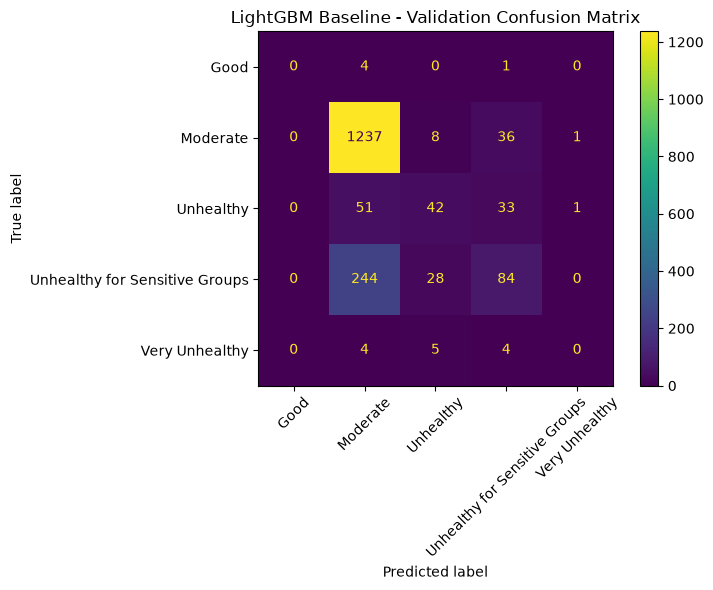

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lgbm_baseline.classes_
).plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title("LightGBM Baseline - Validation Confusion Matrix")

plt.tight_layout()
plt.show()

## 12. Analyze Feature Importance

Feature importance is extracted from the trained baseline LightGBM model to identify which processed features contributed most to the model's predictions.

The features are sorted by their importance values, and the top 20 features are displayed for analysis.


In [14]:
feature_importance = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": lgbm_baseline.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print("Top 20 LightGBM Features:")
display(feature_importance.head(20))

Top 20 LightGBM Features:


,feature,importance
2,numeric__longitude,1030
0,numeric__year,916
1,numeric__latitude,795
25,numeric__max_to_mean_ratio,672
3,numeric__observation_count,597
22,numeric__pm25_rolling_3yr_std,577
12,numeric__seventy_five_percentile,558
11,numeric__ninety_percentile,528
18,numeric__pm25_pct_change_1yr,519
17,numeric__pm25_change_1yr,511


## 13. Visualize Top Feature Importances

The top 20 most important features are visualized using a horizontal bar chart.

The visualization makes it easier to compare the relative importance of the features used by the baseline LightGBM model.


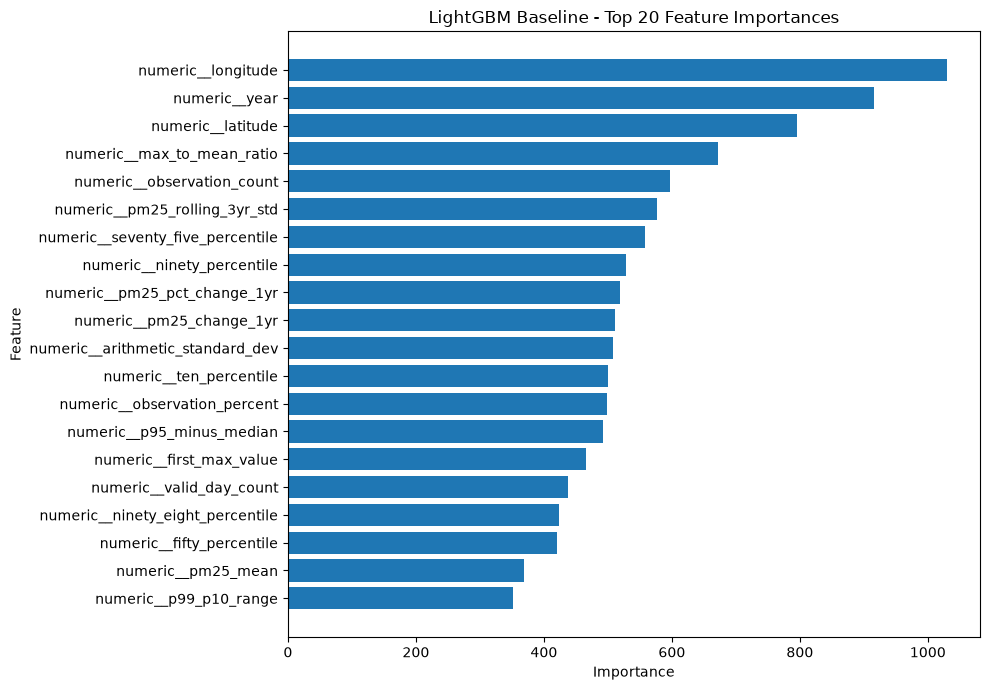

In [15]:
top_features = feature_importance.head(20).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Baseline - Top 20 Feature Importances")

plt.tight_layout()
plt.show()

## 14. Prepare Output Directories

Output directories are prepared for storing the baseline LightGBM results and visualizations.

* `reports/model_results` stores numerical results and evaluation reports.
* `reports/pictures` stores generated plots and figures.

The directories are created automatically if they do not already exist.


In [16]:
results_dir = project_root / "reports" / "model_results"

figures_dir = project_root / "reports" / "pictures"

results_dir.mkdir(parents=True, exist_ok=True)

figures_dir.mkdir(parents=True, exist_ok=True)

print("Output directories ready.")

Output directories ready.


In [17]:
metrics_df = pd.DataFrame({
    "Model": ["LightGBM Baseline"],
    "Accuracy": [accuracy],
    "Macro F1": [macro_f1],
    "Weighted F1": [weighted_f1]
})

metrics_path = results_dir / "lightgbm_baseline_metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Metrics saved to:", metrics_path)

Metrics saved to: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_baseline_metrics.csv


## 15. Save Baseline Evaluation Metrics

The baseline LightGBM evaluation metrics are stored in a structured CSV file.

The saved results include:

* Accuracy
* Macro F1
* Weighted F1

These metrics can be reused later for model comparison and reporting without rerunning the evaluation.


In [18]:
report_dict = classification_report(
    y_val,
    y_val_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = results_dir / "lightgbm_baseline_classification_report.csv"

report_df.to_csv(
    report_path,
    index=True
)

print("Classification report saved to:", report_path)

Classification report saved to: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_baseline_classification_report.csv


## 16. Visualize Overall Validation Metrics

The main validation metrics of the baseline LightGBM model are visualized using a bar chart.

The chart displays the validation **Accuracy** and **Macro F1** scores, providing a concise overview of the model's performance.

The generated figure is saved in the project's `reports/pictures` directory for use in the final report.


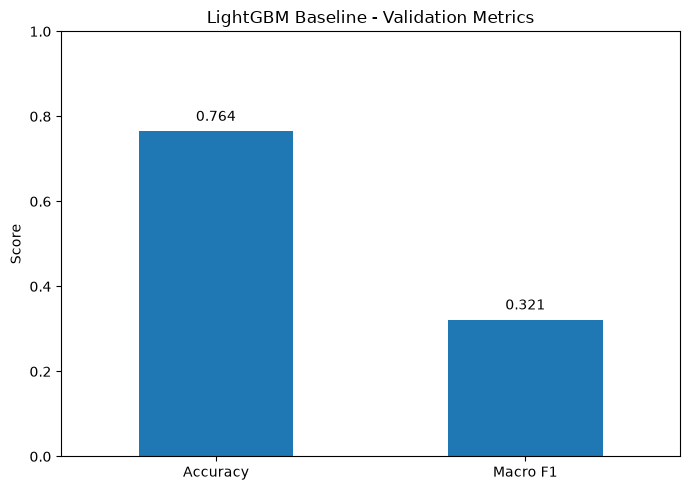

In [ ]:
overall_metrics = pd.Series(
    {
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
    }
)

fig, ax = plt.subplots(figsize=(7, 5))

overall_metrics.plot(kind="bar", ax=ax)

ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("LightGBM Baseline - Validation Metrics")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(overall_metrics.values):
    ax.text(i, min(value + 0.025, 0.97), f"{value:.3f}", ha="center")

plt.tight_layout()

overall_metrics_picture = (
    pictures_dir / "lightgbm_baseline_metrics.png"
)

plt.savefig(
    overall_metrics_picture,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", overall_metrics_picture)

plt.show()

## 17. Save Classification Report and Class-wise Metrics

The validation classification report is converted into a DataFrame and saved as a CSV file for reporting and later model comparison.

The class-wise **Precision, Recall, and F1-score** are also visualized using a bar chart. The chart is saved as a PNG file in the project reports directory.

This provides both numerical evidence and a visual representation of the model's performance across the different PM2.5 risk categories.


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_baseline_classification_report.csv


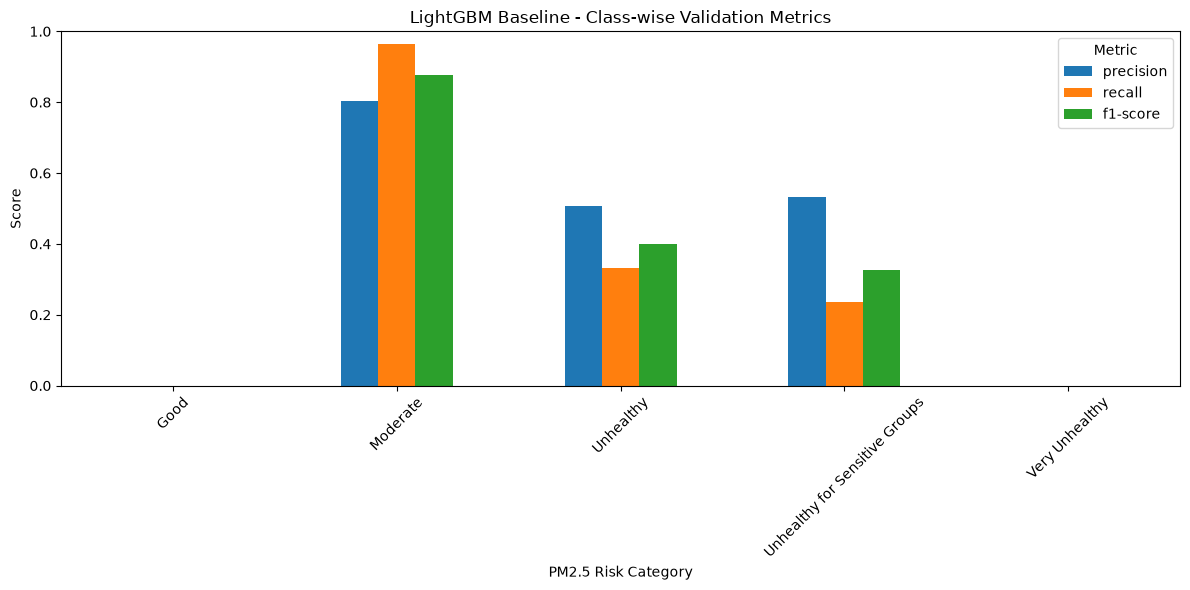

In [ ]:
classification_report_dict = classification_report(
    y_val,
    y_val_pred,
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

classification_report_path = (
    results_dir / "lightgbm_baseline_classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path
)

print("Saved:", classification_report_path)

class_names = [
    label for label in sorted(pd.Series(y_val).dropna().unique())
    if label in classification_report_df.index
]

class_metrics = classification_report_df.loc[
    class_names,
    ["precision", "recall", "f1-score"]
]

ax = class_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_ylim(0, 1)

ax.set_ylabel("Score")

ax.set_xlabel("PM2.5 Risk Category")

ax.set_title(
    "LightGBM Baseline - Class-wise Validation Metrics"
)

ax.tick_params(axis="x", rotation=45)

plt.legend(title="Metric")

plt.tight_layout()

class_metrics_picture = (
    pictures_dir / "lightgbm_baseline_class_metrics.png"
)

plt.savefig(
    class_metrics_picture,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", class_metrics_picture)


plt.show()

## 18. Save the Confusion Matrix

The confusion matrix for the baseline LightGBM model is visualized and saved as a high-resolution PNG image.

The visualization shows the actual PM2.5 risk categories against the predicted categories, making it easier to identify correct classifications and misclassifications.

The saved figure can be used as visual evidence in the final project report.


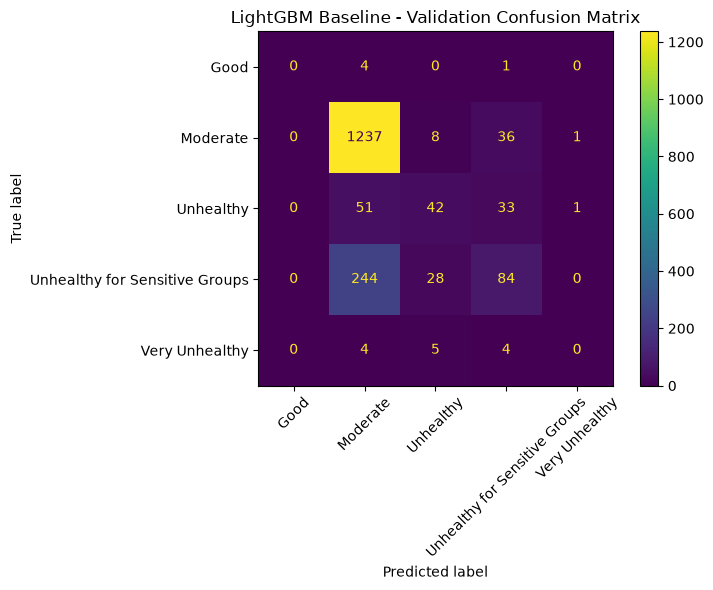

Confusion matrix saved to: c:\Users\User\Desktop\FDM-Mini-Project\reports\pictures\lightgbm_baseline_confusion_matrix.png


In [ ]:
cm_path = figures_dir / "lightgbm_baseline_confusion_matrix.png"

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lgbm_baseline.classes_
).plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title("LightGBM Baseline - Validation Confusion Matrix")

plt.tight_layout()

fig.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Confusion matrix saved to:", cm_path)

## 19. Final Baseline Model Summary

The final validation performance of the baseline LightGBM model is summarized below.

The output check confirms that the required evaluation result files and visualizations have been generated successfully.

This baseline model is used as the reference point for comparison with the tuned LightGBM model developed in the separate hyperparameter tuning notebook.

The test dataset remains untouched and is reserved for the final model evaluation.


In [ ]:
print("FINAL BASELINE MODEL SUMMARY")

expected_outputs = [
    results_dir / "lightgbm_baseline_metrics.csv",
    results_dir / "lightgbm_baseline_classification_report.csv",
    figures_dir / "lightgbm_baseline_confusion_matrix.png",
    figures_dir / "lightgbm_baseline_metrics.png",
    figures_dir / "lightgbm_baseline_class_metrics.png",
]

print("LIGHTGBM BASELINE OUTPUT CHECK")

print("=" * 55)

for output_path in expected_outputs:
    status = "OK" if output_path.exists() else "MISSING"
    print(f"{status:7} | {output_path}")

print("=" * 55)

print("Model: LightGBM Baseline")

print(f"Validation Accuracy: {accuracy:.4f}")

print(f"Validation Macro F1: {macro_f1:.4f}")

print(f"Validation Weighted F1: {weighted_f1:.4f}")

print("Hyperparameter Tuning: False")

print("Model Optimization: False")

FINAL BASELINE MODEL SUMMARY
LIGHTGBM BASELINE OUTPUT CHECK
OK      | c:\Users\User\Desktop\FDM-Mini-Project\reports\model_results\lightgbm_baseline_metrics.csv
OK      | c:\Users\User\Desktop\FDM-Mini-Project\reports\model_results\lightgbm_baseline_classification_report.csv
OK      | c:\Users\User\Desktop\FDM-Mini-Project\reports\pictures\lightgbm_baseline_confusion_matrix.png
OK      | c:\Users\User\Desktop\FDM-Mini-Project\reports\pictures\lightgbm_baseline_metrics.png
OK      | c:\Users\User\Desktop\FDM-Mini-Project\reports\pictures\lightgbm_baseline_class_metrics.png
Model: LightGBM Baseline
Validation Accuracy: 0.7644
Validation Macro F1: 0.3207
Validation Weighted F1: 0.7241
Hyperparameter Tuning: False
Model Optimization: False
